In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [2]:
X,y = make_regression(n_samples=100 , n_targets=1 , n_features=1 , noise=30 )

In [3]:
df = pd.DataFrame(X,y)

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [31]:
pipeline_steps = [
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
]

In [34]:
pipe = Pipeline(pipeline_steps)

In [35]:
pipe.fit(X_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](1,)",[0.06]


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train,X_test,y_train,y_test= train_test_split(X,y, test_size=0.2 , random_state=30)

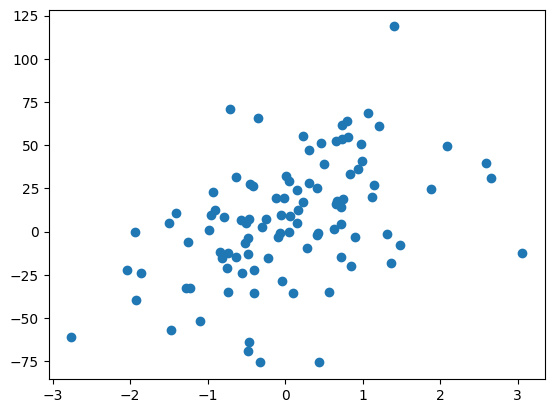

In [38]:
plt.scatter(X,y)

In [39]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[15.23]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.876
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[9.42]


In [40]:
class GDRegressor:
    def __init__(self,epochs,learning_rate):
        self.b=0
        self.m=0
        self.epochs =epochs
        self.lr = learning_rate

    def fit(self,X,y):
        for i in range (self.epochs):
            slope_b = - 2 * np.sum( y - self.m*X.ravel() - self.b)
            slope_m = - 2 * np.sum(( y - self.m*X.ravel() - self.b) * X.ravel())

            self.b = self.b - (self.lr*slope_b)
            self.m = self.m - (self.lr*slope_m)

        print(self.b , self.m)

    def predict(self,X):
        return self.m* X + self.b
    

In [54]:
gd = GDRegressor(500,0.001)

In [55]:
gd.fit(X,y)

6.188691196771083 15.548208575743061


In [56]:
print(lr.coef_)

[15.23110289]


In [57]:
print(lr.intercept_)

5.87554984362875


In [58]:
gd.predict(X)

array([[ 25.08808238],
       [ 14.96373146],
       [ -1.34800221],
       [ 17.40432453],
       [ -1.28664441],
       [  7.21588992],
       [ 17.37942738],
       [ 14.05045919],
       [ -4.82240387],
       [ 28.05192513],
       [ 12.74222231],
       [-22.75686921],
       [ -1.67970095],
       [-23.69527514],
       [-13.70254695],
       [  4.43240413],
       [-15.73941303],
       [ -0.78780752],
       [  7.84948735],
       [ -3.62083764],
       [ 20.6979272 ],
       [ -6.56853698],
       [ 35.34208296],
       [ 10.92710761],
       [-13.34276805],
       [ -0.32243817],
       [ 27.36966662],
       [-12.85243114],
       [ -2.51119697],
       [-16.76197772],
       [  8.55781729],
       [  5.47737094],
       [ 17.42947186],
       [ -1.90903109],
       [ -3.59674293],
       [ 13.40781634],
       [ 11.05599923],
       [ 23.67591011],
       [ 15.95853844],
       [ -6.03146894],
       [  7.02184145],
       [  9.7488183 ],
       [ 16.53591097],
       [ -1